<a href="https://colab.research.google.com/github/Sanjanahraju/Sanjana_is076_parvam_cdsa/blob/main/Diabetes_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("diabetes_risk_dataset.csv")

df.head()

,Patient_ID,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,1,77,Female,33.8,154,93,12.1,5.2,242,194,Low,2169,78.4,8.1,4,No,101.1,52.3,Prediabetes
1,2,54,Male,19.2,123,94,4.6,5.4,212,76,High,1881,16.5,6.6,3,No,60.0,3.7,Low Risk
2,3,25,Male,33.7,141,150,10.8,6.9,247,221,Low,2811,147.9,6.7,10,Yes,114.7,87.3,High Risk
3,4,23,Female,32.8,140,145,11.6,6.8,195,193,Low,2826,98.3,4.4,9,Yes,96.6,76.1,High Risk
4,5,70,Male,33.7,165,90,18.3,5.6,217,170,Moderate,2610,65.8,9.1,5,Yes,107.4,47.7,Prediabetes


In [2]:
df.columns

Index(['Patient_ID', 'age', 'gender', 'bmi', 'blood_pressure',
       'fasting_glucose_level', 'insulin_level', 'HbA1c_level',
       'cholesterol_level', 'triglycerides_level', 'physical_activity_level',
       'daily_calorie_intake', 'sugar_intake_grams_per_day', 'sleep_hours',
       'stress_level', 'family_history_diabetes', 'waist_circumference_cm',
       'diabetes_risk_score', 'diabetes_risk_category'],
      dtype='object')

In [3]:
df = df.drop("Patient_ID", axis=1)

In [4]:
df.isnull().sum()

,0
age,0
gender,0
bmi,0
blood_pressure,0
fasting_glucose_level,0
insulin_level,0
HbA1c_level,0
cholesterol_level,0
triglycerides_level,0
physical_activity_level,0


In [5]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["physical_activity_level"] = le.fit_transform(df["physical_activity_level"])
df["family_history_diabetes"] = le.fit_transform(df["family_history_diabetes"])

In [7]:
df["diabetes_risk_category"] = le.fit_transform(df["diabetes_risk_category"])

In [8]:
X = df.drop("diabetes_risk_category", axis=1)
y = df["diabetes_risk_category"]

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [12]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9983333333333333


In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       469
           1       1.00      1.00      1.00       506
           2       1.00      0.99      1.00       225

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

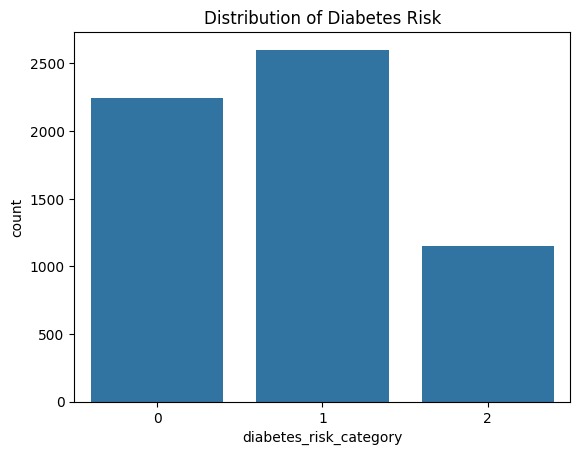

In [28]:
sns.countplot(x="diabetes_risk_category", data=df)
plt.title("Distribution of Diabetes Risk")
plt.show()

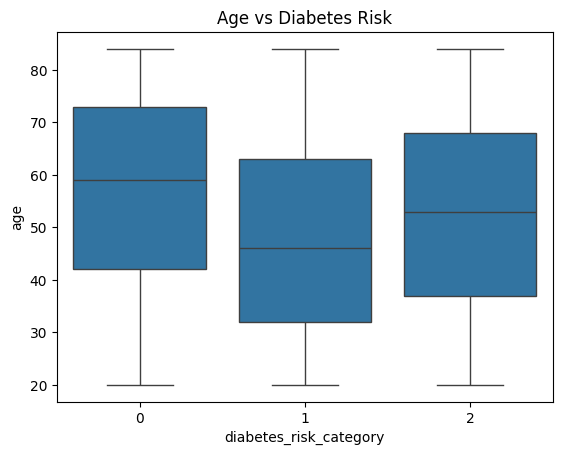

In [24]:
sns.boxplot(x="diabetes_risk_category", y="age", data=df)
plt.title("Age vs Diabetes Risk")
plt.show()

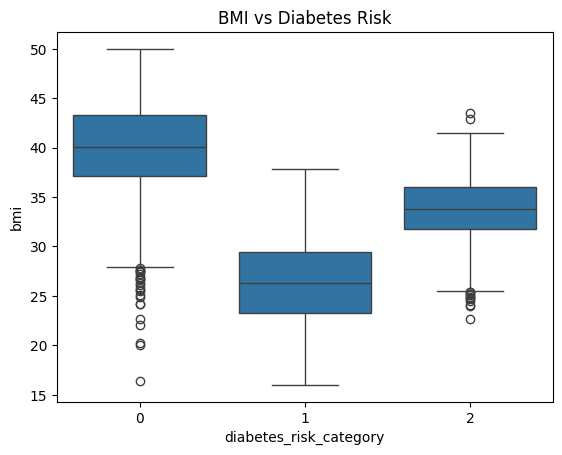

In [25]:
sns.boxplot(x="diabetes_risk_category", y="bmi", data=df)
plt.title("BMI vs Diabetes Risk")
plt.show()

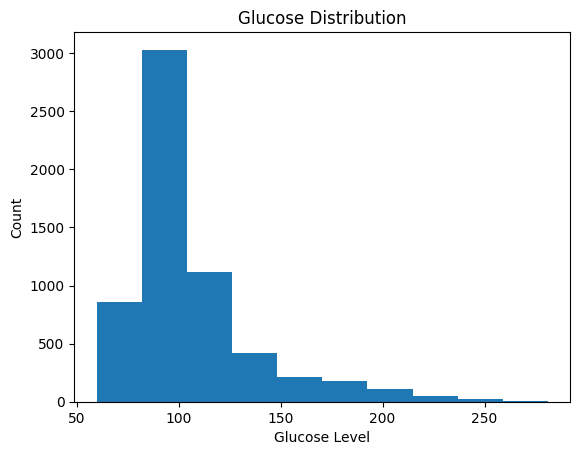

In [26]:
plt.hist(df["fasting_glucose_level"])
plt.title("Glucose Distribution")
plt.xlabel("Glucose Level")
plt.ylabel("Count")
plt.show()

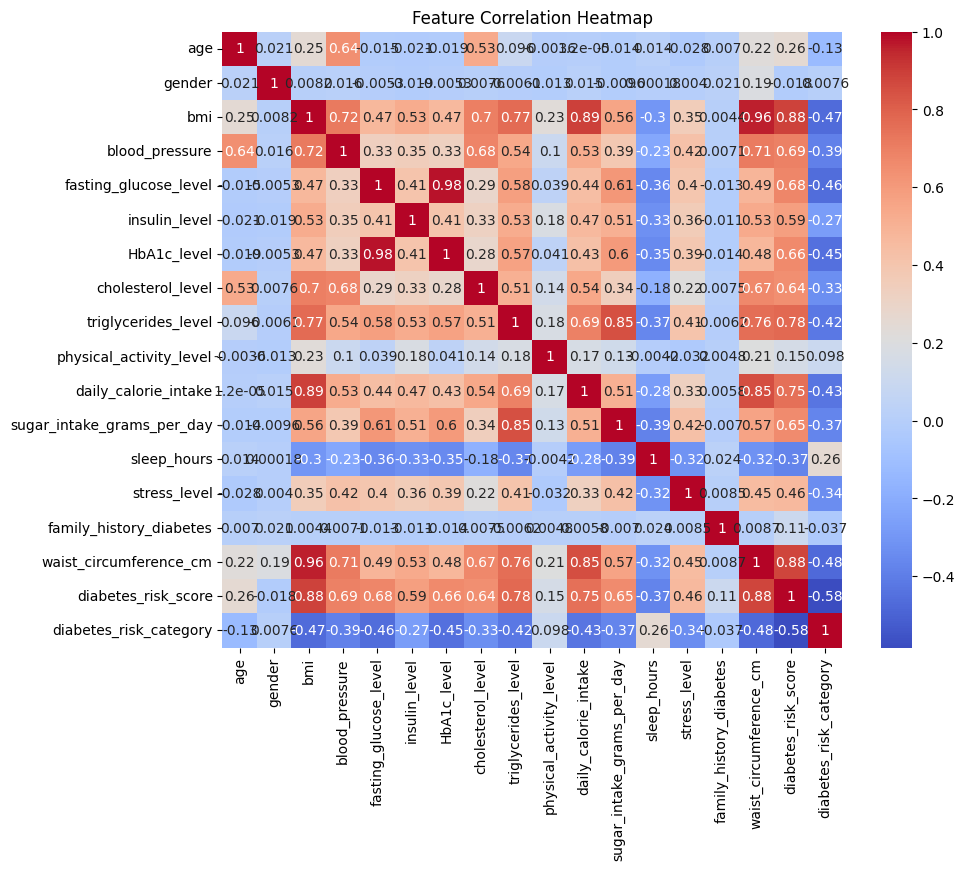

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [17]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [19]:
import numpy as np

sample = X.iloc[0].values.reshape(1, -1)

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

print(prediction)

[2]


In [18]:
import warnings
warnings.filterwarnings("ignore")

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [31]:
results = {}

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    results[name] = acc

    print(name, "Accuracy:", acc)

Logistic Regression Accuracy: 0.9833333333333333
Decision Tree Accuracy: 1.0
Random Forest Accuracy: 0.9991666666666666
SVM Accuracy: 0.9566666666666667
KNN Accuracy: 0.8866666666666667


In [32]:
best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", results[best_model])


Best Model: Decision Tree
Best Accuracy: 1.0


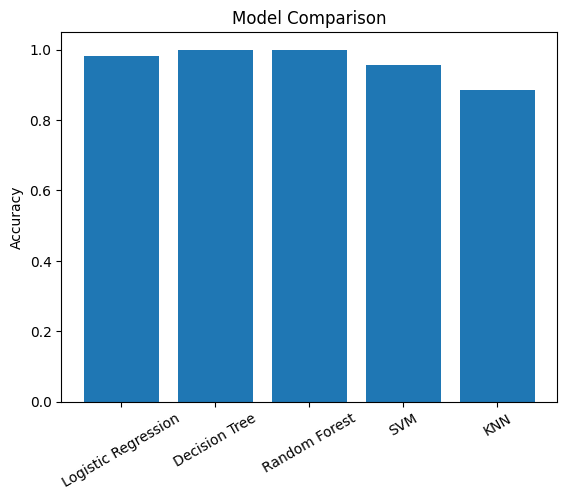

In [33]:
import matplotlib.pyplot as plt

names = list(results.keys())
values = list(results.values())

plt.bar(names, values)
plt.xticks(rotation=30)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()